In [1]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

def load(filename):
    return kagglehub.dataset_load(
        KaggleDatasetAdapter.PANDAS,
        "nikdavis/steam-store-games",
        filename,
    )

steam                = load("steam.csv")
steam_description    = load("steam_description_data.csv")
steam_media          = load("steam_media_data.csv")
steam_requirements   = load("steam_requirements_data.csv")
steam_support        = load("steam_support_info.csv")
steamspy_tags        = load("steamspy_tag_data.csv")

print("steam:              ", steam.shape)
print("steam_description:  ", steam_description.shape)
print("steam_media:        ", steam_media.shape)
print("steam_requirements: ", steam_requirements.shape)
print("steam_support:      ", steam_support.shape)
print("steamspy_tags:      ", steamspy_tags.shape)

/Users/apple/Developer/human-AI-logs/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


steam:               (27075, 18)
steam_description:   (27334, 4)
steam_media:         (27332, 5)
steam_requirements:  (27319, 6)
steam_support:       (27136, 4)
steamspy_tags:       (29022, 372)


## Propose two different definitions of “success” and compare whether they identify the multiple games. 


In [2]:
steam.dtypes

appid                 int64
name                    str
release_date            str
english               int64
developer               str
publisher               str
platforms               str
required_age          int64
categories              str
genres                  str
steamspy_tags           str
achievements          int64
positive_ratings      int64
negative_ratings      int64
average_playtime      int64
median_playtime       int64
owners                  str
price               float64
dtype: object

In [3]:
import numpy as np

# Metric 1: Wilson score lower bound — quality signal that penalises low vote count
# Uses 95% confidence (z=1.96): asks "what's the worst this game plausibly is?"
def wilson_lower(pos, total, z=1.96):
    p = pos / total                          # observed positive ratio
    centre  = p + z**2 / (2 * total)
    margin  = z * np.sqrt(p*(1-p)/total + z**2/(4*total**2))
    denom   = 1 + z**2 / total
    return (centre - margin) / denom

total_ratings = steam['positive_ratings'] + steam['negative_ratings']
valid = total_ratings > 0                    # avoid division by zero

steam['wilson_lower'] = np.where(
    valid,
    wilson_lower(steam['positive_ratings'], total_ratings),
    np.nan
)

# Metric 2: estimated revenue — owners midpoint × price (commercial signal)
def owners_midpoint(s):
    lo, hi = s.replace(',', '').split('-')
    return (int(lo.strip()) + int(hi.strip())) / 2

steam['owners_mid'] = steam['owners'].apply(owners_midpoint)
steam['est_revenue'] = steam['owners_mid'] * steam['price']

# A game is "successful" under a metric if it falls in the top 10%
def top10_mask(series):
    return series >= series.quantile(0.90)

rr_out  = top10_mask(steam['wilson_lower'])
rev_out = top10_mask(steam['est_revenue'])

print(f"Wilson lower top 10% : {rr_out.sum()}")
print(f"Revenue top 10%      : {rev_out.sum()}")
print(f"Both                 : {(rr_out & rev_out).sum()}")

Wilson lower top 10% : 2710
Revenue top 10%      : 2717
Both                 : 936


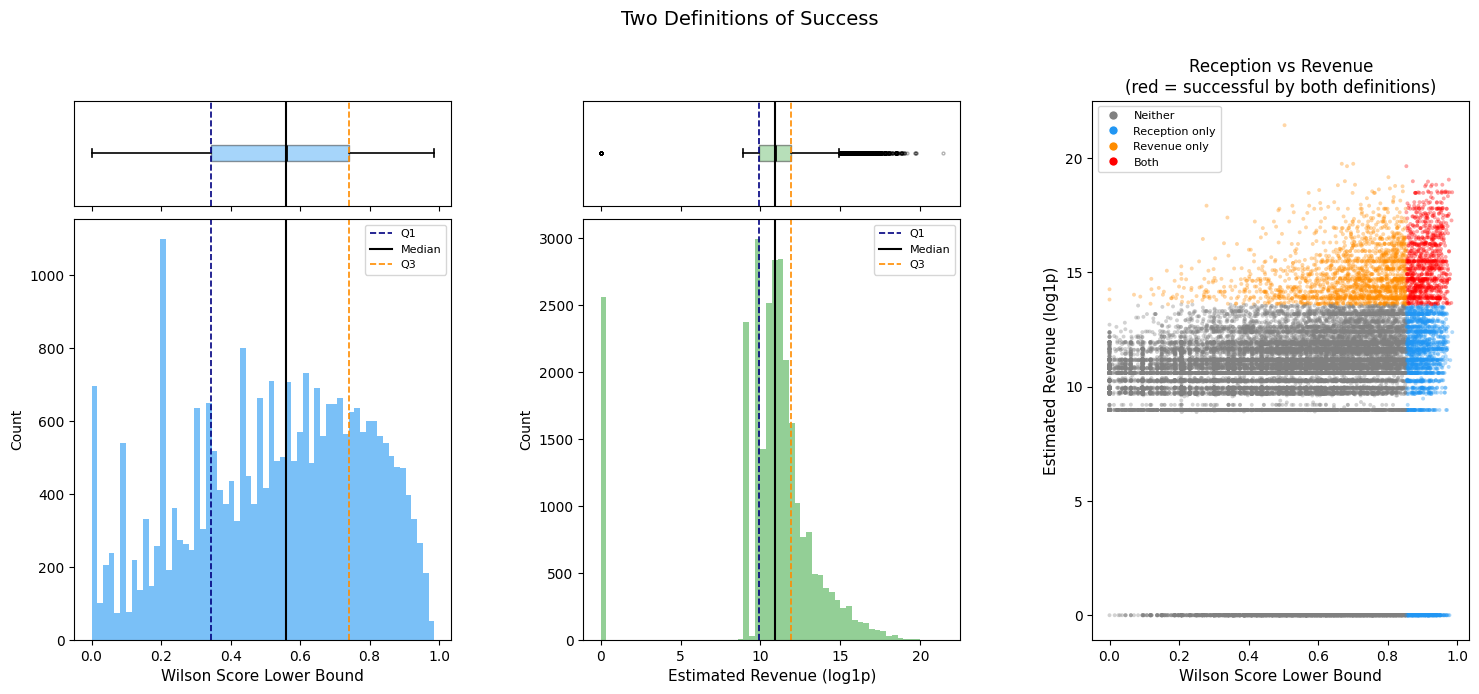

In [4]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from matplotlib.lines import Line2D

both_out = rr_out & rev_out

fig = plt.figure(figsize=(18, 7))
gs = gridspec.GridSpec(2, 3, height_ratios=[1, 4], hspace=0.05, wspace=0.35)

# Stacked boxplot + histogram sharing the same x-axis
def draw_dist(fig, gs_top, gs_bot, series, label, color):
    data = series.dropna().values
    ax_box = fig.add_subplot(gs_top)
    ax_his = fig.add_subplot(gs_bot, sharex=ax_box)

    # Boxplot on top row
    ax_box.boxplot(data, vert=False, patch_artist=True,
                   boxprops=dict(facecolor=color, alpha=0.4),
                   medianprops=dict(color='black', linewidth=2),
                   whiskerprops=dict(linewidth=1.2),
                   capprops=dict(linewidth=1.2),
                   flierprops=dict(marker='o', markersize=2, alpha=0.3))
    ax_box.set_yticks([])
    plt.setp(ax_box.get_xticklabels(), visible=False)

    # Histogram on bottom row with Q1 / median / Q3 reference lines
    ax_his.hist(data, bins=60, color=color, alpha=0.6, edgecolor='none')
    q1, med, q3 = np.quantile(data, [0.25, 0.50, 0.75])
    for ax in (ax_box, ax_his):
        ax.axvline(q1,  color='navy',      linestyle='--', linewidth=1.2, label='Q1')
        ax.axvline(med, color='black',     linestyle='-',  linewidth=1.5, label='Median')
        ax.axvline(q3,  color='darkorange',linestyle='--', linewidth=1.2, label='Q3')

    ax_his.set_xlabel(label, fontsize=11)
    ax_his.set_ylabel('Count', fontsize=10)
    ax_his.legend(fontsize=8)

draw_dist(fig, gs[0, 0], gs[1, 0], steam['wilson_lower'], 'Wilson Score Lower Bound', '#2196F3')
draw_dist(fig, gs[0, 1], gs[1, 1], np.log1p(steam['est_revenue']), 'Estimated Revenue (log1p)', '#4CAF50')

# Scatter: each game coloured by which success definition(s) it satisfies
ax_sc = fig.add_subplot(gs[:, 2])

valid = steam[['wilson_lower', 'est_revenue']].dropna().copy()
valid['log_rev'] = np.log1p(valid['est_revenue'])

color_map = np.where(both_out[valid.index], 'red',
            np.where(rr_out[valid.index],   '#2196F3',
            np.where(rev_out[valid.index],  'darkorange', 'grey')))

ax_sc.scatter(valid['wilson_lower'], valid['log_rev'],
              c=color_map, alpha=0.35, s=8, linewidths=0)

ax_sc.legend(handles=[
    Line2D([0],[0], marker='o', color='w', markerfacecolor='grey',       markersize=7, label='Neither'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#2196F3',    markersize=7, label='Reception only'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='darkorange', markersize=7, label='Revenue only'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='red',        markersize=7, label='Both'),
], fontsize=8)
ax_sc.set_xlabel('Wilson Score Lower Bound', fontsize=11)
ax_sc.set_ylabel('Estimated Revenue (log1p)', fontsize=11)
ax_sc.set_title('Reception vs Revenue\n(red = successful by both definitions)', fontsize=12)

plt.suptitle('Two Definitions of Success', fontsize=14, y=1.01)
plt.show()

conclusion - from the scatter plot, high rating success and high revenue success are quite different

## How does price relate to player reception?


In [5]:
import numpy as np
from scipy.stats import pearsonr, spearmanr
from statsmodels.nonparametric.smoothers_lowess import lowess
from sklearn.tree import DecisionTreeRegressor

# Separate free-to-play (price=0) from paid — F2P is a distinct category
df = steam[['price', 'wilson_lower']].dropna()
f2p  = df[df['price'] == 0]
paid = df[df['price'] > 0]

# Pearson (linear) and Spearman (monotonic) correlations on paid games
pearson_r,  pearson_p  = pearsonr(paid['price'],  paid['wilson_lower'])
spearman_r, spearman_p = spearmanr(paid['price'], paid['wilson_lower'])

# LOWESS on log1p-price so the dense low-price region isn't visually compressed
log_paid_price = np.log1p(paid['price'].values)
smoothed = lowess(paid['wilson_lower'].values, log_paid_price, frac=0.3, return_sorted=True)

# CART on raw price (tree splits in original units, we transform for display)
X = paid['price'].values.reshape(-1, 1)
y = paid['wilson_lower'].values
cart = DecisionTreeRegressor(max_depth=3, random_state=0)
cart.fit(X, y)

# Split thresholds (internal nodes only; leaves have threshold == -2)
split_thresholds = np.unique(cart.tree_.threshold[cart.tree_.threshold != -2])

# Predict over a fine price grid for the step-function overlay
price_grid = np.linspace(paid['price'].min(), paid['price'].max(), 2000).reshape(-1, 1)
cart_pred  = cart.predict(price_grid)

print(f"Pearson r  = {pearson_r:.3f}  (p={pearson_p:.2e})")
print(f"Spearman ρ = {spearman_r:.3f}  (p={spearman_p:.2e})")
print(f"CART splits at prices: {split_thresholds.round(2)}")

Pearson r  = 0.202  (p=3.22e-223)
Spearman ρ = 0.293  (p=0.00e+00)
CART splits at prices: [ 0.87  1.7   4.    6.19  6.99  9.97 15.64]


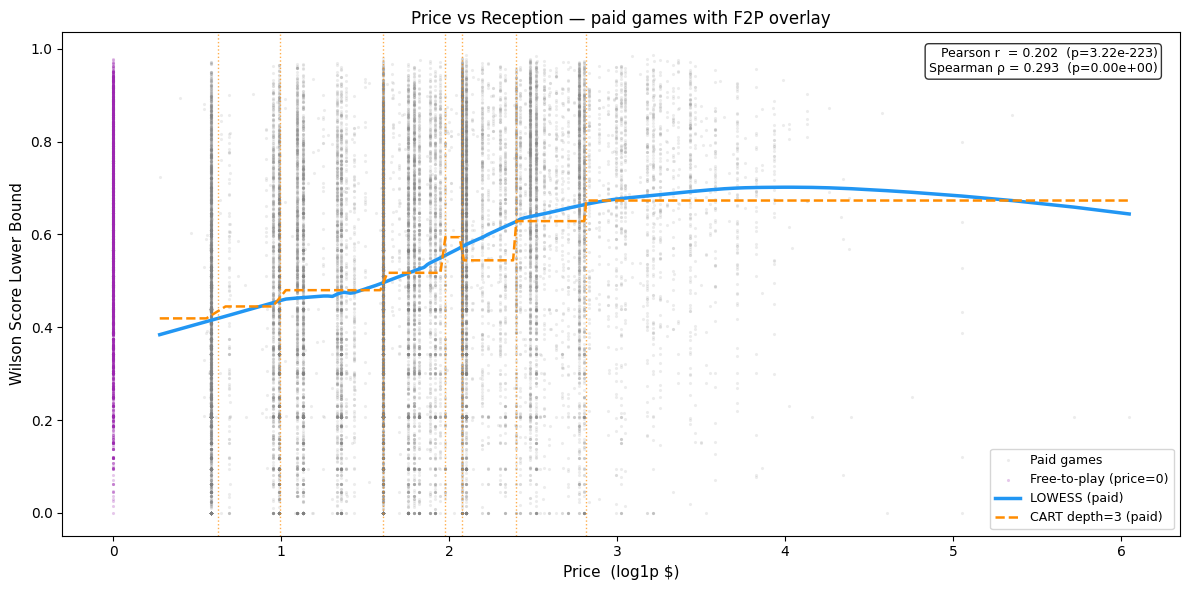

In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(12, 6))

# Paid games scatter (grey, low alpha to show density)
ax.scatter(np.log1p(paid['price']), paid['wilson_lower'],
           c='grey', alpha=0.15, s=5, linewidths=0, label='Paid games')

# F2P games at x=log1p(0)=0 in a distinct colour
ax.scatter(np.zeros(len(f2p)), f2p['wilson_lower'],
           c='#9C27B0', alpha=0.25, s=5, linewidths=0, label='Free-to-play (price=0)')

# LOWESS trend on paid games
ax.plot(smoothed[:, 0], smoothed[:, 1],
        color='#2196F3', linewidth=2.5, label='LOWESS (paid)')

# CART step function and split lines (transform thresholds to log1p scale for display)
ax.plot(np.log1p(price_grid.flatten()), cart_pred,
        color='darkorange', linewidth=1.8, linestyle='--', label='CART depth=3 (paid)')
for thr in split_thresholds:
    ax.axvline(np.log1p(thr), color='darkorange', linestyle=':', linewidth=1, alpha=0.7)

# Correlation box
ax.text(0.98, 0.97,
        f"Pearson r  = {pearson_r:.3f}  (p={pearson_p:.2e})\n"
        f"Spearman ρ = {spearman_r:.3f}  (p={spearman_p:.2e})",
        transform=ax.transAxes, ha='right', va='top', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax.set_xlabel('Price  (log1p $)', fontsize=11)
ax.set_ylabel('Wilson Score Lower Bound', fontsize=11)
ax.set_title('Price vs Reception — paid games with F2P overlay', fontsize=12)
ax.legend(fontsize=9, loc='lower right')
plt.tight_layout()
plt.show()

conclusion - price has a weak positive relationship with reception (Pearson r=0.20, Spearman ρ=0.29). Spearman being higher suggests the trend is monotonic but not strictly linear. CART's primary split is at ~$6.19 (raw price), meaning games above that price tend to have noticeably better reception than cheaper ones. Free-to-play games form a separate cluster at price=0 and should not be mixed with paid games in this analysis.

## How does playtime relate to player reception?  


In [7]:
import numpy as np
from scipy.stats import pearsonr, spearmanr
from statsmodels.nonparametric.smoothers_lowess import lowess
from sklearn.tree import DecisionTreeRegressor

# Use median playtime — more robust than average against hardcore outlier players
# Zero playtime means no tracking data (most games on Steam), not zero play
df = steam[['median_playtime', 'wilson_lower']].dropna()
no_play  = df[df['median_playtime'] == 0]
has_play = df[df['median_playtime'] > 0]

print(f"Zero playtime : {len(no_play)} games ({100*len(no_play)/len(df):.0f}%)")
print(f"Has playtime  : {len(has_play)} games")

# Correlations on games with measurable playtime
pearson_r,  pearson_p  = pearsonr(has_play['median_playtime'],  has_play['wilson_lower'])
spearman_r, spearman_p = spearmanr(has_play['median_playtime'], has_play['wilson_lower'])

# LOWESS on log1p scale — playtime is extremely right-skewed (Dota/CS outliers)
log_playtime = np.log1p(has_play['median_playtime'].values)
smoothed = lowess(has_play['wilson_lower'].values, log_playtime, frac=0.3, return_sorted=True)

# CART on raw playtime to find natural reception thresholds
X = has_play['median_playtime'].values.reshape(-1, 1)
y = has_play['wilson_lower'].values
cart = DecisionTreeRegressor(max_depth=3, random_state=0)
cart.fit(X, y)

split_thresholds = np.unique(cart.tree_.threshold[cart.tree_.threshold != -2])
playtime_grid    = np.linspace(has_play['median_playtime'].min(),
                               has_play['median_playtime'].max(), 2000).reshape(-1, 1)
cart_pred        = cart.predict(playtime_grid)

print(f"\nPearson r  = {pearson_r:.3f}  (p={pearson_p:.2e})")
print(f"Spearman ρ = {spearman_r:.3f}  (p={spearman_p:.2e})")
print(f"Root split : {cart.tree_.threshold[0]:.0f} min  (~{cart.tree_.threshold[0]/60:.1f} hrs)")

Zero playtime : 20905 games (77%)
Has playtime  : 6170 games



Pearson r  = 0.027  (p=3.53e-02)
Spearman ρ = 0.141  (p=7.27e-29)
Root split : 462 min  (~7.7 hrs)


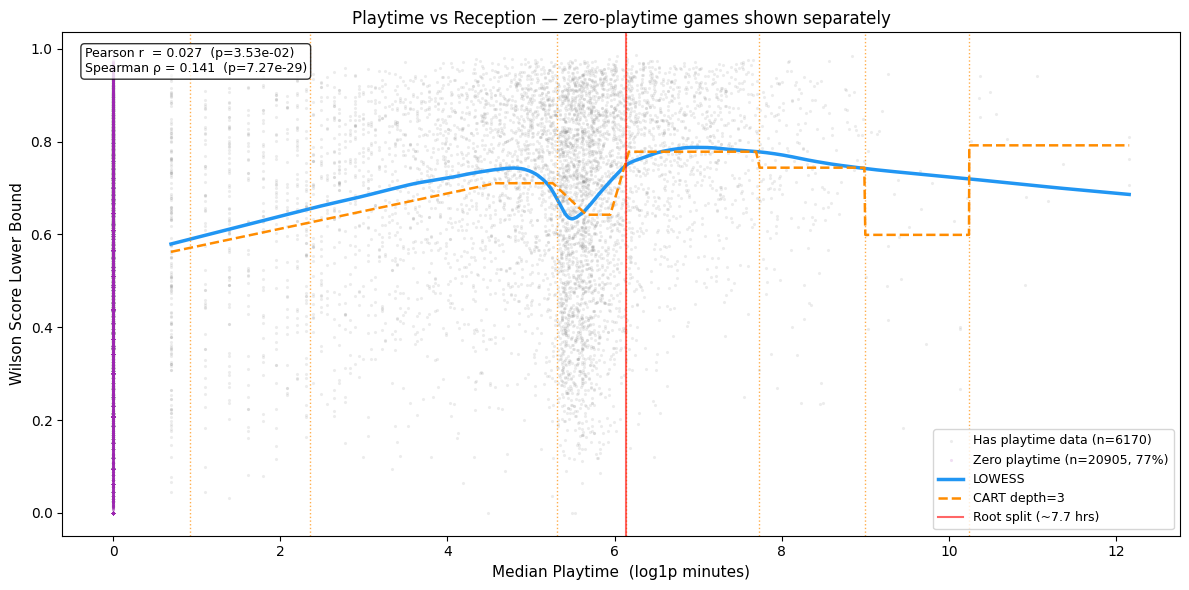

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))

# Games with playtime data (grey) and zero-playtime games at x=0 (purple)
ax.scatter(np.log1p(has_play['median_playtime']), has_play['wilson_lower'],
           c='grey', alpha=0.15, s=5, linewidths=0, label=f'Has playtime data (n={len(has_play)})')
ax.scatter(np.zeros(len(no_play)), no_play['wilson_lower'],
           c='#9C27B0', alpha=0.15, s=5, linewidths=0, label=f'Zero playtime (n={len(no_play)}, 77%)')

# LOWESS trend fitted on games with playtime
ax.plot(smoothed[:, 0], smoothed[:, 1],
        color='#2196F3', linewidth=2.5, label='LOWESS')

# CART step function with vertical lines at split thresholds
ax.plot(np.log1p(playtime_grid.flatten()), cart_pred,
        color='darkorange', linewidth=1.8, linestyle='--', label='CART depth=3')
for thr in split_thresholds:
    ax.axvline(np.log1p(thr), color='darkorange', linestyle=':', linewidth=1, alpha=0.7)

ax.text(0.02, 0.97,
        f"Pearson r  = {pearson_r:.3f}  (p={pearson_p:.2e})\n"
        f"Spearman ρ = {spearman_r:.3f}  (p={spearman_p:.2e})",
        transform=ax.transAxes, ha='left', va='top', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Label the root split in hours for readability
root = cart.tree_.threshold[0]
ax.axvline(np.log1p(root), color='red', linewidth=1.5, alpha=0.6,
           label=f'Root split (~{root/60:.1f} hrs)')

ax.set_xlabel('Median Playtime  (log1p minutes)', fontsize=11)
ax.set_ylabel('Wilson Score Lower Bound', fontsize=11)
ax.set_title('Playtime vs Reception — zero-playtime games shown separately', fontsize=12)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

conclusion - 77% of games have zero median playtime and form a separate group. among the remaining 23%, playtime has almost no linear correlation with reception (Pearson r=0.027) but a weak monotonic one (Spearman ρ=0.14). CART's primary split at ~7.7 hrs suggests a threshold effect: games where a typical player puts in 7+ hours score noticeably better, likely because sustained playtime reflects genuine enjoyment.